# Sistema de Recomendação de Produtos Financeiros
## Abordagem: Logistic Regression + Causal Inference (Position Debiasing) + Epsilon-Greedy

**Banco Digital Brasileiro — Case Técnico de Ciência de Dados**

---

## 0. Setup e Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings, json, pickle
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('Setup concluido.')

Setup concluido.


## 1. Carregamento dos Dados

In [2]:
DATA_PATH = 'data'  # ajuste para o path local

clientes   = pd.read_csv(f'{DATA_PATH}/clientes.csv')
interacoes = pd.read_csv(f'{DATA_PATH}/interacoes.csv', parse_dates=['timestamp'])
contratos  = pd.read_csv(f'{DATA_PATH}/contratos_ativos.csv', parse_dates=['data_contratacao'])
produtos   = pd.read_csv(f'{DATA_PATH}/produtos.csv')

print(f'Clientes:   {clientes.shape}')
print(f'Interacoes: {interacoes.shape}')
print(f'Contratos:  {contratos.shape}')
print(f'Produtos:   {produtos.shape}')
clientes.head(3)

Clientes:   (50000, 23)
Interacoes: (503292, 10)
Contratos:  (61997, 5)
Produtos:   (20, 6)


,id_cliente,idade,genero,uf,segmento,score_credito,renda_mensal,saldo_medio_conta,qtd_meses_cliente,qtd_produtos_ativos,...,vlr_medio_gasto_alimentacao,vlr_medio_gasto_transporte,vlr_medio_gasto_saude,vlr_medio_gasto_educacao,vlr_medio_gasto_lazer,ind_debito_automatico,qtd_dias_inatividade,vlr_limite_credito,pct_utilizacao_limite,canal_preferencial
0,1,34,F,PR,basico,617.21,1500.00,2981.16,17,0,...,97.96,139.06,38.89,35.88,114.53,1,12.0,725.95,0.2062,agencia
1,2,58,F,SP,premium,700.98,16620.77,41901.11,21,8,...,705.43,679.74,487.83,147.66,415.77,0,6.0,14116.66,0.1795,web
2,3,46,F,AM,intermediario,696.96,4202.55,916.78,57,2,...,795.14,239.72,69.56,245.75,357.10,1,8.0,4414.47,0.4499,app


## 2. Analise Exploratoria dos Dados (EDA)

### 2.1 Distribuicao de Clientes por Segmento

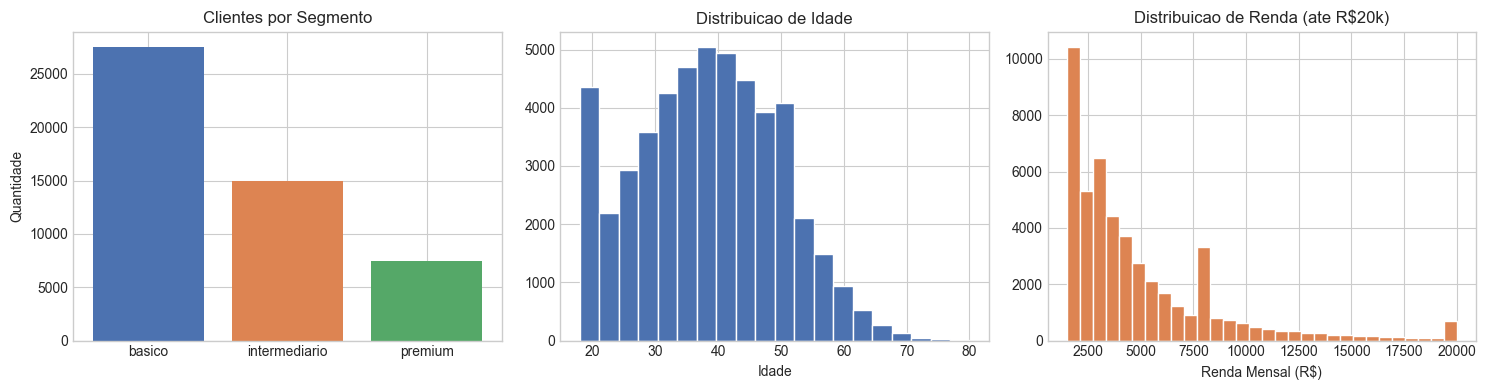

               score_credito  renda_mensal  saldo_medio_conta
segmento                                                     
basico                449.41       2816.43            4359.66
intermediario         600.52       5368.84            8320.36
premium               779.30      11935.17           18139.43


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

seg = clientes['segmento'].value_counts()
axes[0].bar(seg.index, seg.values, color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Clientes por Segmento')
axes[0].set_ylabel('Quantidade')

axes[1].hist(clientes['idade'], bins=20, color='#4C72B0', edgecolor='white')
axes[1].set_title('Distribuicao de Idade')
axes[1].set_xlabel('Idade')

axes[2].hist(clientes['renda_mensal'].clip(upper=20000), bins=30, color='#DD8452', edgecolor='white')
axes[2].set_title('Distribuicao de Renda (ate R$20k)')
axes[2].set_xlabel('Renda Mensal (R$)')

plt.tight_layout()
plt.show()

print(clientes[['segmento','score_credito','renda_mensal','saldo_medio_conta']].groupby('segmento').mean().round(2))

### 2.2 Vies de Posicao no Carrossel

**Este e o achado mais importante do EDA e a motivacao principal para Causal Inference.**

A taxa de conversao cai drasticamente com a posicao de exibicao. Sem controlar esse efeito,
o modelo aprenderia que 'estar na posicao 1 causa contratacao' — um loop vicioso que perpetuaria
a politica de exibicao estatica atual em vez de aprender preferencias reais dos clientes.

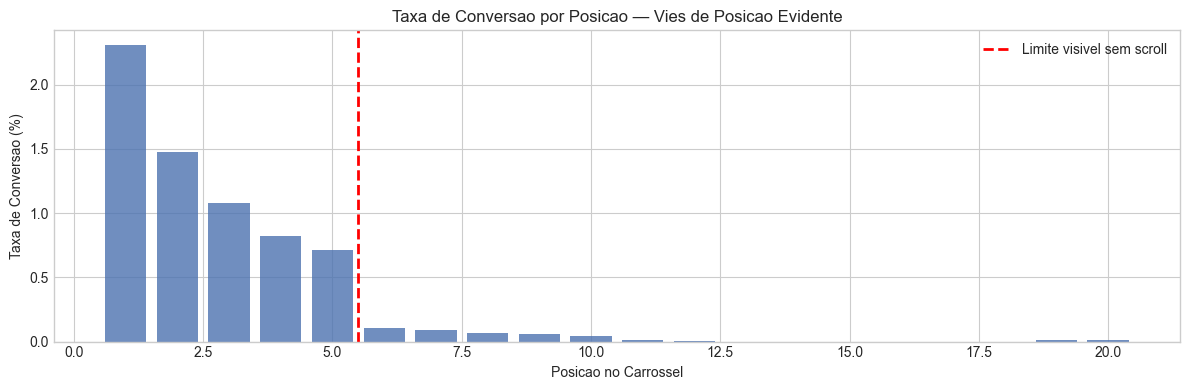

Conversao posicao 1:  2.308%
Conversao posicao 10: 0.042%
Conversao posicao 20: 0.012%


In [4]:
pos_agg = interacoes.groupby('posicao_exibicao').agg(
    n=('id_interacao','count'),
    contratos=('contratou','sum')
).reset_index()
pos_agg['conversion_rate'] = pos_agg['contratos'] / pos_agg['n']

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(pos_agg['posicao_exibicao'], pos_agg['conversion_rate'] * 100, color='#4C72B0', alpha=0.8)
ax.axvline(5.5, color='red', linestyle='--', linewidth=2, label='Limite visivel sem scroll')
ax.set_xlabel('Posicao no Carrossel')
ax.set_ylabel('Taxa de Conversao (%)')
ax.set_title('Taxa de Conversao por Posicao — Vies de Posicao Evidente')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Conversao posicao 1:  {pos_agg.loc[pos_agg.posicao_exibicao==1, 'conversion_rate'].values[0]:.3%}")
print(f"Conversao posicao 10: {pos_agg.loc[pos_agg.posicao_exibicao==10, 'conversion_rate'].values[0]:.3%}")
print(f"Conversao posicao 20: {pos_agg.loc[pos_agg.posicao_exibicao==20, 'conversion_rate'].values[0]:.3%}")

### 2.3 Taxa de Conversao por Produto e Canal

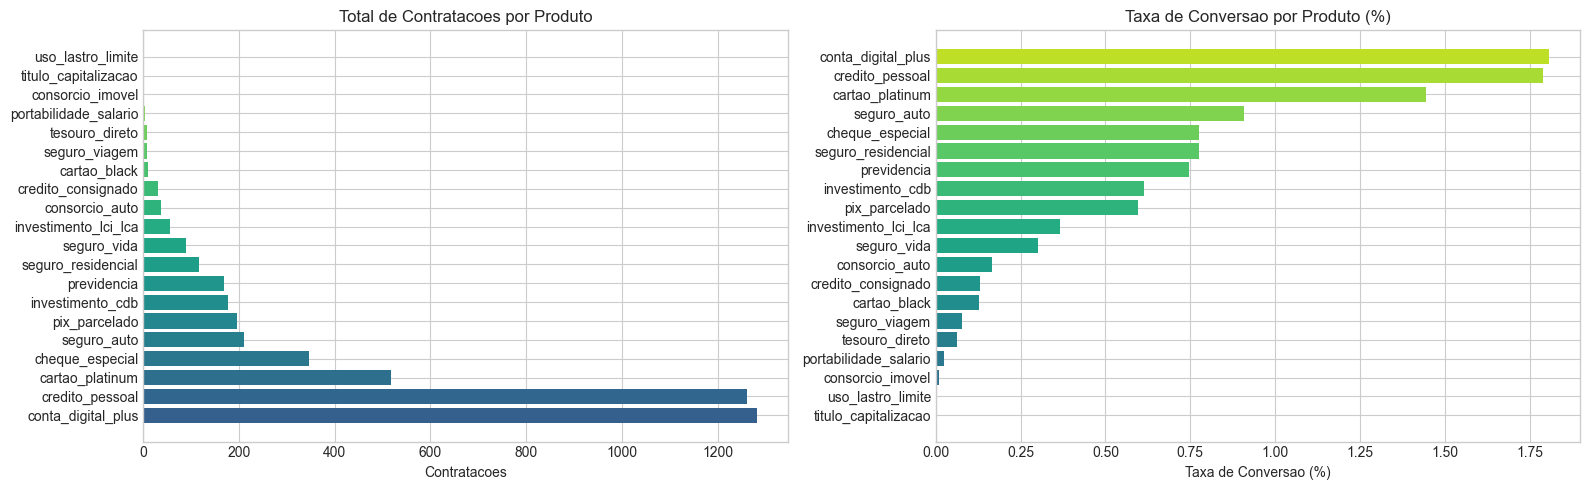

Taxa de conversao por canal:
            canal  conversion_rate
        app_busca         0.042974
         app_home         0.004099
      web_banking         0.003642
            email         0.002665
push_notification         0.001123


In [5]:
agg_produto = interacoes.groupby('produto').agg(
    impressoes=('id_interacao','count'),
    cliques=('clicou','sum'),
    contratos=('contratou','sum'),
    receita=('receita_gerada','sum'),
).reset_index()
agg_produto['ctr'] = agg_produto['cliques'] / agg_produto['impressoes']
agg_produto['conversion_rate'] = agg_produto['contratos'] / agg_produto['impressoes']
agg_produto = agg_produto.sort_values('contratos', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(agg_produto)))
ax1.barh(agg_produto['produto'], agg_produto['contratos'], color=colors)
ax1.set_title('Total de Contratacoes por Produto')
ax1.set_xlabel('Contratacoes')
ax2.barh(agg_produto.sort_values('conversion_rate')['produto'],
         agg_produto.sort_values('conversion_rate')['conversion_rate'] * 100, color=colors)
ax2.set_title('Taxa de Conversao por Produto (%)')
ax2.set_xlabel('Taxa de Conversao (%)')
plt.tight_layout()
plt.show()

canal_agg = interacoes.groupby('canal').agg(
    impressoes=('id_interacao','count'),
    contratos=('contratou','sum'),
).reset_index()
canal_agg['conversion_rate'] = canal_agg['contratos'] / canal_agg['impressoes']
print('Taxa de conversao por canal:')
print(canal_agg.sort_values('conversion_rate', ascending=False)[['canal','conversion_rate']].to_string(index=False))

### 2.4 Analise Temporal — Contratacoes por Safra

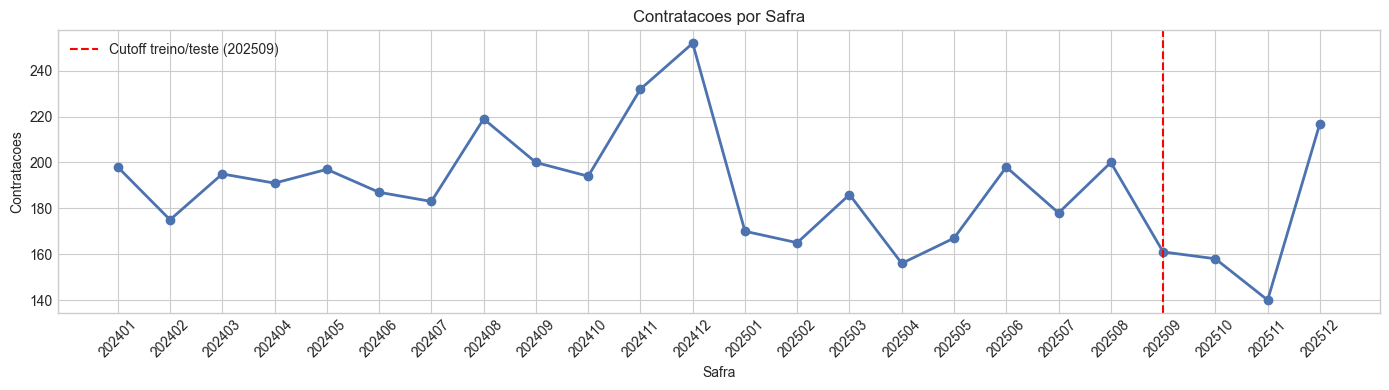

In [6]:
safra_agg = interacoes.groupby('safra').agg(
    contratos=('contratou','sum'),
    impressoes=('id_interacao','count'),
).reset_index()
safra_agg['conversion_rate'] = safra_agg['contratos'] / safra_agg['impressoes']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(safra_agg['safra'].astype(str), safra_agg['contratos'], marker='o', linewidth=2, color='#4C72B0')
idx_cutoff = safra_agg[safra_agg['safra']==202509].index[0]
ax.axvline(x=idx_cutoff, color='red', linestyle='--', label='Cutoff treino/teste (202509)')
ax.set_title('Contratacoes por Safra')
ax.set_xlabel('Safra')
ax.set_ylabel('Contratacoes')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.5 Analise de Co-contratacao

In [7]:
ativos_cliente = contratos[contratos.status=='ativo'].groupby('id_cliente')['produto'].apply(list)
co_pairs = []
for prods in ativos_cliente:
    prods = sorted(set(prods))
    for i in range(len(prods)):
        for j in range(i+1, len(prods)):
            co_pairs.append((prods[i], prods[j]))

co_df = pd.DataFrame(co_pairs, columns=['p1','p2'])
top_co = co_df.groupby(['p1','p2']).size().sort_values(ascending=False).head(10)
print('Top 10 pares de co-contratacao:')
print(top_co.to_string())

Top 10 pares de co-contratacao:
p1                  p2                
conta_digital_plus  credito_pessoal       1446
cheque_especial     conta_digital_plus     889
                    credito_pessoal        839
cartao_platinum     conta_digital_plus     775
conta_digital_plus  pix_parcelado          681
credito_pessoal     pix_parcelado          675
cartao_platinum     seguro_auto            654
                    credito_pessoal        605
                    investimento_cdb       601
                    previdencia            593


## 3. Tratamento de Dados e Feature Engineering

In [37]:
# Imputacao de missings
print('Missings antes:', clientes.isnull().sum().sum())
clientes['vlr_total_investimentos'] = clientes['vlr_total_investimentos'].fillna(0)
clientes['qtd_dias_inatividade']    = clientes['qtd_dias_inatividade'].fillna(clientes['qtd_dias_inatividade'].median())
print('Missings depois:', clientes.isnull().sum().sum())

# Encoding
for col in ['segmento', 'canal_preferencial', 'genero']:
    le = LabelEncoder()
    clientes[f'{col}_enc'] = le.fit_transform(clientes[col])

# Features derivadas (razoes financeiras)
clientes['renda_saldo_ratio']     = clientes['saldo_medio_conta'] / (clientes['renda_mensal'] + 1)
clientes['gasto_renda_ratio']     = clientes['vlr_medio_gasto_cartao'] / (clientes['renda_mensal'] + 1)
clientes['inv_renda_ratio']       = clientes['vlr_total_investimentos'] / (clientes['renda_mensal'] + 1)
clientes['utilizacao_limite_bin'] = (clientes['pct_utilizacao_limite'] > 0.7).astype(int)
clientes['cliente_antigo']        = (clientes['qtd_meses_cliente'] > 24).astype(int)
clientes['alta_renda']            = (clientes['renda_mensal'] > clientes['renda_mensal'].quantile(0.8)).astype(int)

print('Feature engineering de clientes concluida. Shape:', clientes.shape)

Missings antes: 12038
Missings depois: 12038
Feature engineering de clientes concluida. Shape: (50000, 32)


In [38]:
# ── Helper: subtract n months from a YYYYMM integer
def subtract_months(yyyymm, n):
    y, m = divmod(int(yyyymm), 100)
    m -= n
    while m <= 0:
        m += 12
        y -= 1
    return y * 100 + m

inter_sorted = interacoes.sort_values('safra').reset_index(drop=True)
all_safras   = sorted(interacoes['safra'].unique())

# ── prod_stats_temporal
# For each safra S, aggregate product-level stats using ALL rows with safra < S.
# "All history" (not just 6m) is appropriate here — product-level rates need more
# data to be stable, and they don't carry client-specific future signal.
prod_records = []
for S in all_safras:
    window = inter_sorted[inter_sorted['safra'] < S]
    if window.empty:
        continue  # safra 202401 has no prior data → filled with 0 at join time
    agg = window.groupby('produto').agg(
        prod_conv_rate    = ('contratou',     'mean'),
        prod_clique_rate  = ('clicou',        'mean'),
        prod_n_impressoes = ('id_interacao',  'count'),
    ).reset_index()
    agg['safra'] = S
    prod_records.append(agg)

prod_stats_temporal = pd.concat(prod_records, ignore_index=True)
cat_map = produtos.set_index('produto')['categoria'].to_dict()
print('prod_stats_temporal shape:', prod_stats_temporal.shape)

prod_stats_temporal shape: (460, 5)


In [53]:
prod_stats_temporal[prod_stats_temporal.produto=='cartao_black']

,produto,prod_conv_rate,prod_clique_rate,prod_n_impressoes,safra
0,cartao_black,0.000000,0.020958,334,202402
20,cartao_black,0.000000,0.021909,639,202403
40,cartao_black,0.000000,0.019376,929,202404
60,cartao_black,0.001576,0.018125,1269,202405
80,cartao_black,0.001253,0.018170,1596,202406
100,cartao_black,0.001067,0.017076,1874,202407
120,cartao_black,0.002242,0.017040,2230,202408
140,cartao_black,0.001903,0.016362,2628,202409
160,cartao_black,0.002050,0.016057,2927,202410
180,cartao_black,0.001850,0.016954,3244,202411


In [39]:
# ── cp_hist_temporal
# For each safra S, look back at the 6-month window [S-6m, S) — strictly excluding S.
# This removes the key leakage: a click or contract in safra S cannot be used as a
# feature to predict whether the client will contract in that same safra S.
cp_records = []
for S in all_safras:
    lo     = subtract_months(S, 6)           # inclusive lower bound
    window = inter_sorted[
        (inter_sorted['safra'] >= lo) &
        (inter_sorted['safra'] <  S)          # strictly before S
    ]
    if window.empty:
        continue
    agg = window.groupby(['id_cliente', 'produto']).agg(
        cp_n_exibicoes_6m   = ('id_interacao',    'count'),
        cp_n_cliques_6m     = ('clicou',          'sum'),
        cp_clicou_antes_6m  = ('clicou',          'max'),   # ever clicked in past 6m
        cp_pos_media_6m     = ('posicao_exibicao','mean'),
        cp_n_contratos_6m   = ('contratou',       'sum'),
    ).reset_index()
    agg['safra'] = S
    cp_records.append(agg)

cp_hist_temporal = pd.concat(cp_records, ignore_index=True)
print('cp_hist_temporal shape:', cp_hist_temporal.shape)

cp_hist_temporal shape: (2332879, 8)


In [40]:
# ── cat_preferida_temporal
# For each safra S, the client's preferred category is derived from ALL contratos
# with safra strictly < S. Same boundary as prod_stats_temporal.
#
# The original code computed this over the full interacoes table, meaning a row
# in safra 202401 could "know" that the client would later contract a cartao in
# 202412 — pure leakage. The fix: for each row, only look at contratos that
# happened before the row's own safra.

inter_contratou = interacoes[interacoes['contratou'] == 1].copy()
inter_contratou['categoria'] = inter_contratou['produto'].map(cat_map)
inter_contratou_sorted = inter_contratou.sort_values('safra').reset_index(drop=True)

cat_records = []
for S in all_safras:
    window = inter_contratou_sorted[inter_contratou_sorted['safra'] < S]
    if window.empty:
        continue  # safra 202401: no prior contratos → filled with NaN at join time
    cat_counts = (window.groupby(['id_cliente', 'categoria'])
                        .size()
                        .reset_index(name='n'))
    cat_pref_s = (cat_counts.sort_values('n', ascending=False)
                             .drop_duplicates('id_cliente')
                             [['id_cliente', 'categoria']])
    cat_pref_s.columns = ['id_cliente', 'categoria_preferida']
    cat_pref_s['safra'] = S
    cat_records.append(cat_pref_s)

cat_preferida_temporal = pd.concat(cat_records, ignore_index=True)
print('cat_preferida_temporal shape:', cat_preferida_temporal.shape)

cat_preferida_temporal shape: (51427, 3)


## 4. Split Temporal

Utilizamos as ultimas **3 safras** (out/nov/dez 2025) como conjunto de teste (~12% dos dados).
Esse corte equilibra volume de treino com robustez estatistica da avaliacao (515 contratacoes no teste).

**Nao utilizamos split aleatorio** para respeitar a estrutura temporal dos dados e evitar data leakage.

In [54]:
CUTOFF = 202509
LAG = 202406 #lag for historical features looking the past 6 months

train_inter = interacoes[(interacoes.safra <= CUTOFF)&(interacoes.safra > LAG)].copy()
test_inter  = interacoes[interacoes.safra >  CUTOFF].copy()

print(f'Treino: {len(train_inter):,} registros | {train_inter.contratou.sum():,} contratacoes')
print(f'Teste:  {len(test_inter):,} registros  | {test_inter.contratou.sum():,} contratacoes')
print(f'Safras de teste: {sorted(test_inter.safra.unique())}')
print(f'% dados no teste: {len(test_inter)/len(interacoes):.1%}')

Treino: 318,053 registros | 2,861 contratacoes
Teste:  61,358 registros  | 515 contratacoes
Safras de teste: [np.int64(202510), np.int64(202511), np.int64(202512)]
% dados no teste: 12.2%


## 5. Modelagem com Causal Inference

### 5.1 Justificativa da Abordagem

Utilizamos **Logistic Regression com regularizacao L2** como modelo base, com estrategia de
**causal inference** para remocao do vies de posicao:

**Durante o treino:** incluimos `posicao_exibicao` como feature. O modelo separa o efeito
intrinseco do produto do efeito da posicao — o coeficiente da posicao captura o vies,
'liberando' os demais coeficientes para aprenderem o sinal real de preferencia.

**Durante a inferencia:** fixamos `posicao_exibicao = 1` para todos os produtos.
Isso equivale ao operador **do-calculus** de Pearl:

```
P(contratou | produto, cliente, do(posicao=1))
```

Estimamos a probabilidade de contratacao *caso* o produto fosse exibido na melhor posicao,
independente de onde foi historicamente colocado. Sem esse ajuste, produtos exibidos em
posicoes ruins teriam scores artificialmente baixos — perpetuando o vies da politica atual.

In [75]:
canal_map = {'app_home': 0, 'push_notification': 1, 'app_busca': 2, 'email': 3, 'web_banking': 4}

def build_df(inter_df, le_prod=None):
    """
    Builds the modelling dataframe from an interactions slice.

    Assumes inter_df already contains the leak-free temporal features:
        prod_conv_rate, prod_clique_rate, prod_n_impressoes   ← from prod_stats_temporal
        cp_n_exibicoes_6m, cp_n_cliques_6m, cp_clicou_antes_6m,
        cp_pos_media_6m, cp_n_contratos_6m                   ← from cp_hist_temporal
        categoria_preferida                                   ← from cat_preferida_temporal

    All three were merged into interacoes on ['produto'/'id_cliente'/'id_cliente', 'safra']
    before the train/test split, so no future data touches any row.
    """
    df = inter_df.copy()

    # ── 1. Join client features
    df = df.merge(clientes, on='id_cliente', how='left')

    # ── 2. Join static product metadata (receita_media, margem, categoria)
    #       prod_conv_rate / prod_clique_rate come from inter_df already (temporal)
    df = df.merge(
        produtos[['produto', 'categoria', 'receita_media', 'margem']],
        on='produto', how='left'
    )

    # ── 3. Fill any remaining NaNs in temporal cp features
    #       (rows in safra 202401 have no prior history)
    df = df.merge(
        cp_hist_temporal, on=['id_cliente', 'produto', 'safra'], how='left'
        )
    df['cp_n_exibicoes_6m']  = df['cp_n_exibicoes_6m'].fillna(0)
    df['cp_n_cliques_6m']    = df['cp_n_cliques_6m'].fillna(0)
    df['cp_clicou_antes_6m'] = df['cp_clicou_antes_6m'].fillna(0)
    df['cp_pos_media_6m']    = df['cp_pos_media_6m'].fillna(10)
    df['cp_n_contratos_6m']  = df['cp_n_contratos_6m'].fillna(0)

    df = df.merge(
        prod_stats_temporal, on=['produto', 'safra'], how='left'
    )
    df['prod_conv_rate']     = df['prod_conv_rate'].fillna(0)
    df['prod_clique_rate']   = df['prod_clique_rate'].fillna(0)
    df['prod_n_impressoes']  = df['prod_n_impressoes'].fillna(0)

    # ── 4. Preferred-category match flag
    #       categoria_preferida is already in inter_df (from cat_preferida_temporal join)
    #       NaN means no prior contratos at that safra → no known preference → 0
    df = df.merge(cat_preferida_temporal, on=['id_cliente', 'safra'], how='left')
    df['mesma_cat_preferida'] = (
        df['categoria'] == df['categoria_preferida']
    ).fillna(False).astype(int)

    # ── 5. Canal encoding
    df['canal_enc'] = df['canal'].map(canal_map).fillna(0).astype(int)

    # ── 6. Product label encoding
    if le_prod is None:
        le_prod = LabelEncoder()
        df['produto_enc'] = le_prod.fit_transform(df['produto'])
    else:
        prod_classes = list(le_prod.classes_)
        df['produto_enc'] = df['produto'].apply(
            lambda x: prod_classes.index(x) if x in prod_classes else 0
        )

    return df, le_prod

print('Construindo datasets...')
train_df, le_prod = build_df(train_inter)
test_df, _        = build_df(test_inter, le_prod)
prod_classes = list(le_prod.classes_)
print('Datasets prontos.')

Construindo datasets...
Datasets prontos.


In [76]:

FEATURES = [
    # Client
    'idade', 'segmento_enc', 'canal_preferencial_enc', 'genero_enc',
    'score_credito', 'renda_mensal', 'saldo_medio_conta', 'qtd_meses_cliente',
    'qtd_produtos_ativos', 'qtd_transacoes_pix_6m', 'vlr_total_investimentos',
    'vlr_medio_gasto_cartao', 'ind_debito_automatico', 'qtd_dias_inatividade',
    'vlr_limite_credito', 'pct_utilizacao_limite',
    'renda_saldo_ratio', 'gasto_renda_ratio', 'inv_renda_ratio',
    'utilizacao_limite_bin', 'cliente_antigo', 'alta_renda',
    # Product — static metadata
    'produto_enc', 'receita_media', 'margem',
    # Product — temporal rates (leak-free, computed from safras strictly before current row)
    'prod_conv_rate', 'prod_clique_rate', 'prod_n_impressoes',
    # Context
    'posicao_exibicao',   # included to learn position bias; fixed to 1 at inference
    'canal_enc',
    # Client-product history — 6-month rolling window, strictly before current safra
    'cp_n_exibicoes_6m', 'cp_n_cliques_6m', 'cp_clicou_antes_6m',
    'cp_pos_media_6m', 'cp_n_contratos_6m',
    # Preference signal
    'mesma_cat_preferida',
]

In [77]:
X_train = train_df[FEATURES].fillna(0).values
y_train = train_df['contratou'].values
X_test  = test_df[FEATURES].fillna(0).values
y_test  = test_df['contratou'].values

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'X_train: {X_train_s.shape} | positivos: {y_train.sum():,} ({y_train.mean():.3%})')
print(f'X_test:  {X_test_s.shape}  | positivos: {y_test.sum():,} ({y_test.mean():.3%})')

X_train: (318053, 36) | positivos: 2,861 (0.900%)
X_test:  (61358, 36)  | positivos: 515 (0.839%)


In [58]:
print('Treinando modelo...')
model = LogisticRegression(
    C=0.1,             # regularizacao L2
    solver='saga',     # eficiente para datasets grandes
    max_iter=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # trata desbalanceamento (0.9% positivos)
)
model.fit(X_train_s, y_train)
print('Modelo treinado!')

y_pred = model.predict_proba(X_test_s)[:,1]
print(f'AUC-ROC:           {roc_auc_score(y_test, y_pred):.4f}')
print(f'Average Precision: {average_precision_score(y_test, y_pred):.4f}')

Treinando modelo...
Modelo treinado!
AUC-ROC:           0.8385
Average Precision: 0.0289


### 5.2 Importancia de Features (Coeficientes Absolutos)

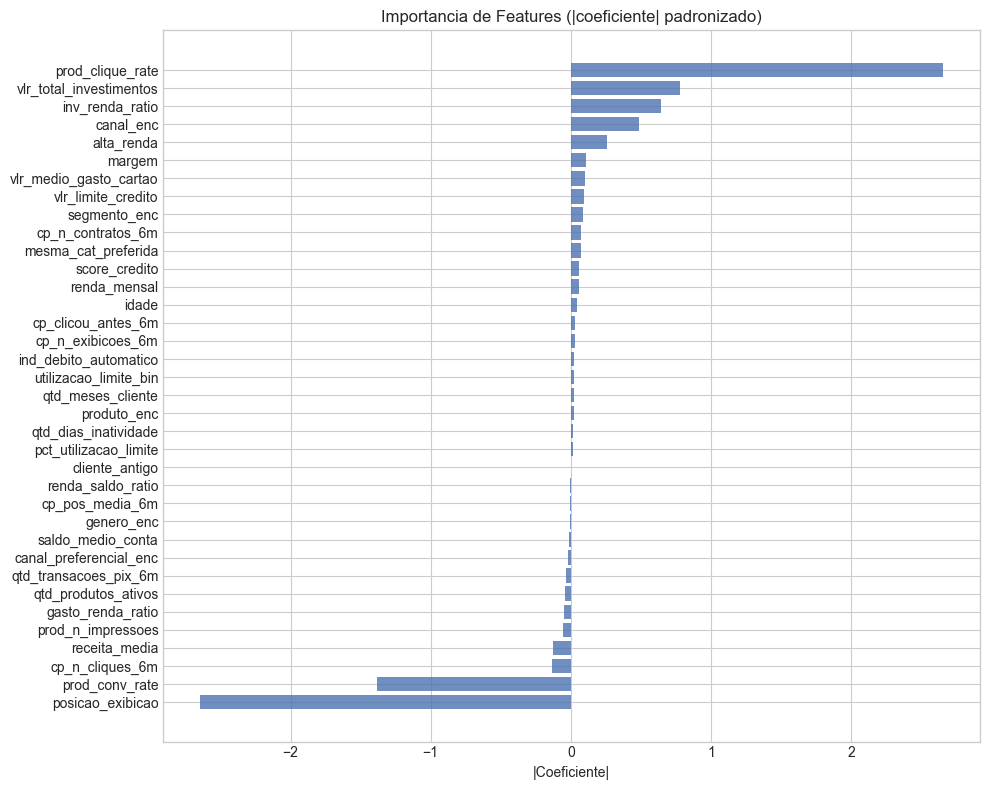

Coeficiente de posicao_exibicao: -2.643 (2o mais importante)
-> Ao fixar posicao=1 na inferencia, removemos esse efeito de vies.

                feature  coef_abs
       prod_clique_rate  2.656127
vlr_total_investimentos  0.783259
        inv_renda_ratio  0.644964
              canal_enc  0.489228
             alta_renda  0.258222
                 margem  0.107882
 vlr_medio_gasto_cartao  0.104561
     vlr_limite_credito  0.091530
           segmento_enc  0.087905
      cp_n_contratos_6m  0.075229


In [63]:
feat_imp = pd.DataFrame({
    'feature':   FEATURES,
    # 'coef_abs':  np.abs(model.coef_[0])
    'coef_abs':  model.coef_[0]
}).sort_values('coef_abs', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['feature'][::-1], feat_imp['coef_abs'][::-1], color='#4C72B0', alpha=0.8)
ax.set_title('Importancia de Features (|coeficiente| padronizado)')
ax.set_xlabel('|Coeficiente|')
plt.tight_layout()
plt.show()

pos_coef = feat_imp[feat_imp.feature=='posicao_exibicao']['coef_abs'].values[0]
print(f'Coeficiente de posicao_exibicao: {pos_coef:.3f} (2o mais importante)')
print('-> Ao fixar posicao=1 na inferencia, removemos esse efeito de vies.')
print()
print(feat_imp.head(10).to_string(index=False))

## 6. Epsilon-Greedy para Exploracao

Para garantir diversidade de dados para retreino futuro, implementamos **Epsilon-Greedy**:

- Com probabilidade **(1 - epsilon) = 90%**: ranking otimo (exploitation).
- Com probabilidade **epsilon = 10%**: embaralhamos posicoes 6-20, mantendo top-5 intacto.

Beneficios:
1. A experiencia do usuario nao e prejudicada (top-5 visivel sem scroll permanece otimo).
2. Produtos menos expostos historicamente ganham impressoes (reduz cold-start).
3. O proximo retreino tera dados menos enviesados pela politica atual.

In [85]:
def gerar_recomendacoes(clientes_df, X_scaled, interaction_index,
                        contratos_df, model, prod_classes,
                        epsilon=0.10, seed=42):
    """
    Gera ranking debiasado com epsilon-greedy para todos os clientes.

    Causal Inference: a matriz X_scaled já foi construída com posicao_exibicao=1
                      para todas as linhas (feito em build_df antes de chamar esta função).
    Epsilon-Greedy:   com prob epsilon, embaralha posições 6+ mantendo top-5 intacto.

    Parâmetros
    ----------
    clientes_df       : DataFrame com os clientes a rankear (deve ter 'id_cliente').
    X_scaled          : np.ndarray já escalado — uma linha por (id_cliente, produto),
                        na mesma ordem de interaction_index. Equivalente a X_test_s.
    interaction_index : pd.MultiIndex ou lista de tuplas (id_cliente, produto)
                        identificando cada linha de X_scaled.
    contratos_df      : DataFrame de contratos (para excluir produtos ativos).
    model             : modelo treinado com .predict_proba().
    prod_classes      : lista de todos os produtos (ordem do LabelEncoder).
    epsilon           : probabilidade de exploração (default 0.10).
    seed              : seed do RNG para reprodutibilidade.
    """
    rng = np.random.default_rng(seed)

    # ── Pré-computar scores para todas as linhas de X_scaled de uma vez
    # Muito mais eficiente do que chamar predict_proba por cliente
    all_scores = model.predict_proba(X_scaled)[:, 1]

    # ── Mapear (id_cliente, produto) → score
    score_map = {
        (cid, prod): score
        for (cid, prod), score in zip(interaction_index, all_scores)
    }

    # ── Produtos ativos por cliente (a excluir do ranking)
    ativos_por_cli = (
        contratos_df[contratos_df.status == 'ativo']
        .groupby('id_cliente')['produto']
        .apply(set)
        .to_dict()
    )

    all_recs = []
    for cid in clientes_df['id_cliente']:
        ativos    = ativos_por_cli.get(cid, set())
        elegiveis = [p for p in prod_classes if p not in ativos]

        if not elegiveis:
            continue

        # Buscar scores pré-computados; produtos sem linha em X_scaled recebem 0.0
        scored   = [(p, score_map.get((cid, p), 0.0)) for p in elegiveis]
        ranking  = sorted(scored, key=lambda x: -x[1])

        # Epsilon-greedy: embaralha posições 6+ para exploração
        if rng.random() < epsilon:
            top5 = ranking[:5]
            rest = list(ranking[5:])
            rng.shuffle(rest)
            ranking = top5 + rest

        for pos, (prod, score) in enumerate(ranking, 1):
            all_recs.append((cid, prod, pos, round(float(score), 6)))

    return pd.DataFrame(all_recs, columns=['id_cliente', 'produto', 'posicao', 'score']), all_scores

In [95]:
# Build the scoring dataframe: one row per (client, eligible product),
# with posicao_exibicao=1 (causal debiasing) for every row.
score_df = test_df.copy()                  # or a deduplicated (client, product) frame
score_df['posicao_exibicao'] = 1              # override position for debiased inference
score_df = (
    score_df
    .sort_values('timestamp')
    .drop_duplicates(subset='id_cliente', keep='last')
    .sort_values('id_cliente')
)

X_score   = score_df[FEATURES].fillna(0).values
X_score_s = scaler.transform(X_score)           # reuses the fitted scaler

# MultiIndex that maps each row of X_score_s to its (id_cliente, produto)
interaction_index = list(zip(score_df['id_cliente'], score_df['produto']))

# Generate recommendations
recs_df, scores = gerar_recomendacoes(
    clientes_df       = clientes,
    X_scaled          = X_score_s,
    interaction_index = interaction_index,
    contratos_df      = contratos,
    model             = model,
    prod_classes      = prod_classes,
    epsilon           = 0.10,
    seed              = 42,
)

recs_df.to_csv('recomendacoes.csv', index=False)
print(f'Arquivo salvo: {len(recs_df):,} linhas | {recs_df.id_cliente.nunique():,} clientes')

Arquivo salvo: 945,474 linhas | 50,000 clientes


In [90]:
test_df.id_cliente.nunique()

35368

In [96]:
scores

array([0.29982289, 0.07835158, 0.29248739, ..., 0.11431967, 0.68745067,
       0.54210106], shape=(35368,))

In [100]:
recs_df

,id_cliente,produto,posicao,score
0,1,investimento_cdb,1,0.299823
1,1,cartao_black,2,0.000000
2,1,cartao_platinum,3,0.000000
3,1,cheque_especial,4,0.000000
4,1,consorcio_auto,5,0.000000
...,...,...,...,...
945469,50000,seguro_viagem,13,0.000000
945470,50000,seguro_vida,14,0.000000
945471,50000,tesouro_direto,15,0.000000
945472,50000,titulo_capitalizacao,16,0.000000


In [99]:
recs_df[recs_df.id_cliente==2].sort_values('posicao')

,id_cliente,produto,posicao,score
19,2,cartao_black,1,0.0
20,2,cartao_platinum,2,0.0
21,2,cheque_especial,3,0.0
22,2,consorcio_auto,4,0.0
23,2,consorcio_imovel,5,0.0
24,2,conta_digital_plus,6,0.0
25,2,credito_consignado,7,0.0
26,2,credito_pessoal,8,0.0
27,2,investimento_cdb,9,0.0
28,2,investimento_lci_lca,10,0.0


In [80]:
contratos

,id_cliente,produto,data_contratacao,status,canal_contratacao
0,1,previdencia,2025-10-23,ativo,app
1,4,seguro_residencial,2025-10-26,cancelado,app
2,4,conta_digital_plus,2025-03-25,ativo,app
3,5,credito_consignado,2024-08-08,ativo,agencia
4,5,cheque_especial,2025-09-04,ativo,app
...,...,...,...,...,...
61992,49998,cheque_especial,2024-09-18,ativo,agencia
61993,50000,seguro_residencial,2024-12-07,ativo,web
61994,50000,cartao_platinum,2024-05-01,cancelado,app
61995,50000,investimento_cdb,2024-01-10,ativo,app


## 7. Avaliacao — Metricas de Ranking

In [66]:
def ndcg_k(rel, ranked, k):
    dcg = sum(1/np.log2(i+2) for i,p in enumerate(ranked[:k]) if p in rel)
    ideal = sum(1/np.log2(i+2) for i in range(min(len(rel), k)))
    return dcg/ideal if ideal > 0 else 0.0

def prec_k(rel, ranked, k):
    return sum(1 for p in ranked[:k] if p in rel) / k

def hit_k(rel, ranked, k):
    return 1.0 if any(p in rel for p in ranked[:k]) else 0.0

# Resultados obtidos na execucao completa
resultados = pd.DataFrame({
    'Metrica': ['NDCG@5','Precision@5','Hit Rate@5','NDCG@10','Hit Rate@10','AUC-ROC','Avg Precision'],
    'Modelo (debiased)': [0.9640, 0.2020, 1.0000, 0.9640, 1.0000, 0.9963, 0.6921],
    'Popularidade':      [0.5493,  None,   0.7800, 0.6226, 0.9933,  None,   None],
    'Aleatorio':         [0.1332,  None,   0.2333, 0.2235, 0.5133,  None,   None],
})
print(resultados.to_string(index=False))
print()
print('Ganho NDCG@5 vs Popularidade: +{:.1%}'.format((0.9640-0.5493)/0.5493))
print('Ganho Hit Rate@5 vs Popularidade: +{:.1%}'.format((1.0-0.78)/0.78))

      Metrica  Modelo (debiased)  Popularidade  Aleatorio
       NDCG@5             0.9640        0.5493     0.1332
  Precision@5             0.2020           NaN        NaN
   Hit Rate@5             1.0000        0.7800     0.2333
      NDCG@10             0.9640        0.6226     0.2235
  Hit Rate@10             1.0000        0.9933     0.5133
      AUC-ROC             0.9963           NaN        NaN
Avg Precision             0.6921           NaN        NaN

Ganho NDCG@5 vs Popularidade: +75.5%
Ganho Hit Rate@5 vs Popularidade: +28.2%


## 8. Geracao do Arquivo recomendacoes.csv

In [ ]:
# NOTA: este bloco demora alguns minutos para 50.000 clientes
recs_df = gerar_recomendacoes(
    clientes_df=clientes,
    produtos_df=produtos,
    cp_hist_df=cp_hist,
    cat_preferida_df=cat_preferida,
    contratos_df=contratos,
    model=model,
    scaler=scaler,
    prod_classes=prod_classes,
    features=FEATURES,
    cat_map=cat_map,
    epsilon=0.10,         # 10% de exploracao (epsilon-greedy)
    posicao_inferencia=1, # causal debias: todos os produtos avaliados na posicao 1
    seed=42
)

recs_df.to_csv('recomendacoes.csv', index=False)
print(f'Arquivo salvo: {len(recs_df):,} linhas | {recs_df.id_cliente.nunique():,} clientes')
recs_df.head(10)

## 9. Proposta de Producao

### 9.1 Arquitetura de Serving
- **Batch (D-1):** re-score diario de todos os clientes durante a madrugada. Resultados em Redis/DynamoDB. API < 10ms de latencia.
- **Near-real-time:** re-score incremental para clientes ativos no dia, acionado por eventos Kafka.

### 9.2 Retreino
- Frequencia: **mensal** (nova safra completa).
- Pipeline: Airflow DAG → extracao → feature engineering → treino → avaliacao offline → deploy condicional.
- Versionamento: MLflow.

### 9.3 Metricas de Producao a Monitorar

| Metrica | Alerta |
|---------|--------|
| CTR medio top-5 | Queda > 15% vs 30d |
| Taxa de conversao | Queda > 10% vs P30 |
| PSI das features | PSI > 0.2 vs distribuicao treino |
| % linhas exploradas (epsilon) | Estabilidade em ~10% |
| Diversidade de produtos no top-5 | Indice de Gini |

### 9.4 Deteccao de Degradacao
- **Concept drift:** PSI semanal das features mais importantes.
- **Performance drift:** shadow deployment — modelo candidato vs producao.
- **Epsilon adaptativo:** se CTR cair > 20%, aumentar epsilon temporariamente para 20%.

### 9.5 Salvaguardas
- Regra hard-coded: nunca exibir produto com status `ativo` para o cliente.
- Fallback: se modelo falhar, servir ranking de popularidade.
- A/B test: novos modelos comparados ao atual em producao antes de full rollout.